<a href="https://colab.research.google.com/github/Banu-Liyanage/Medical-Image-Processing/blob/main/main/Image_Processing_Techniques/Test_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [5]:
# Read image in grayscale
input_image_path = '/content/BrainProtonDensitySlice.png'
input_image = cv2.imread(input_image_path, cv2.IMREAD_GRAYSCALE)

# Histogram

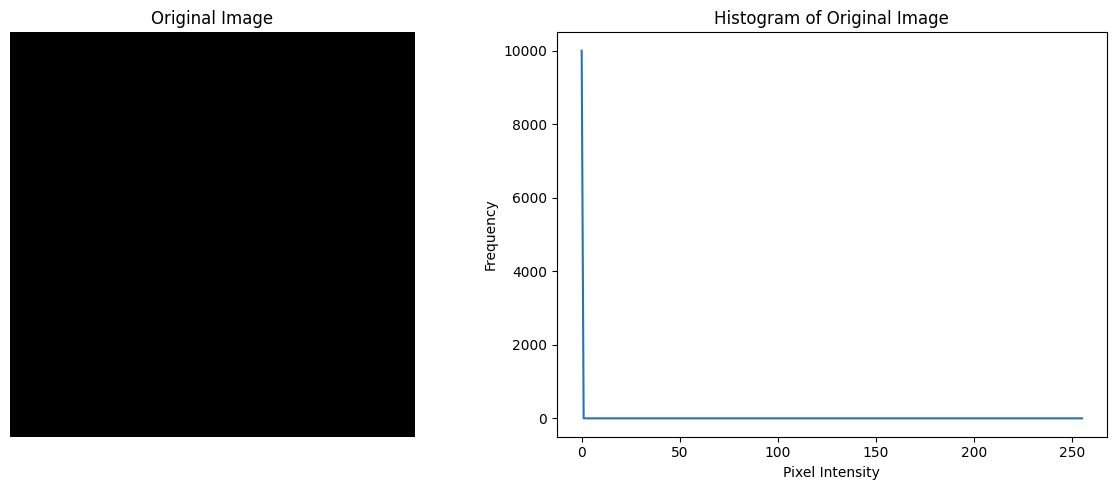

In [4]:
# Calculate histogram
hist, bins = np.histogram(input_image.ravel(), 256, [0, 256])

# Plot image and histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].plot(hist)
axes[1].set_title('Histogram of Original Image')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Point Operations - Intensity Transformations


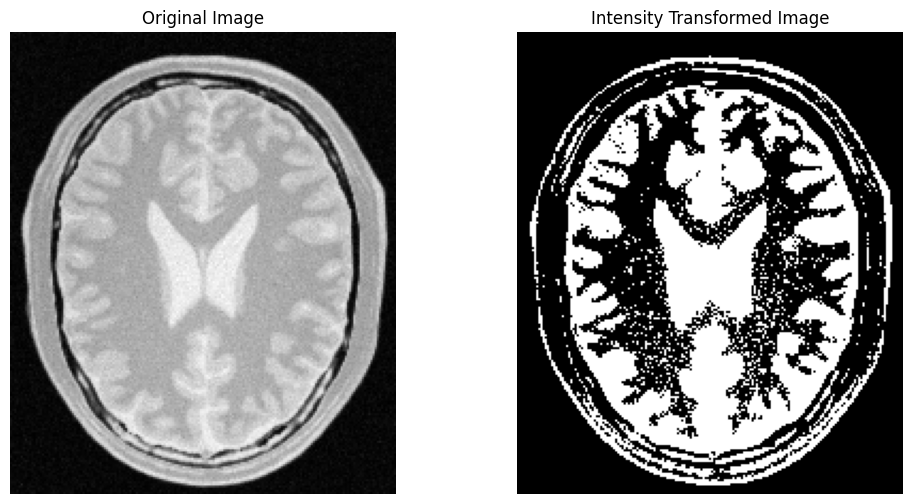

In [ ]:
# Intensity transformation
threshold_value = 175
white_value = 255  # White
black_value = 0   # Black

# Binary Thresholding
_, transformed_image = cv2.threshold(input_image, threshold_value, white_value, cv2.THRESH_BINARY)

# Display original and transformed images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(transformed_image, cmap='gray')
axes[1].set_title('Intensity Transformed Image')
axes[1].axis('off')

plt.show()

# Point Operations - Sigmoid filter


/tmp/ipython-input-4225137740.py:11: RuntimeWarning: overflow encountered in exp
  sigmoid_image = output_min + (output_max - output_min) / (1.0 + np.exp(alpha * (beta - img_float)))


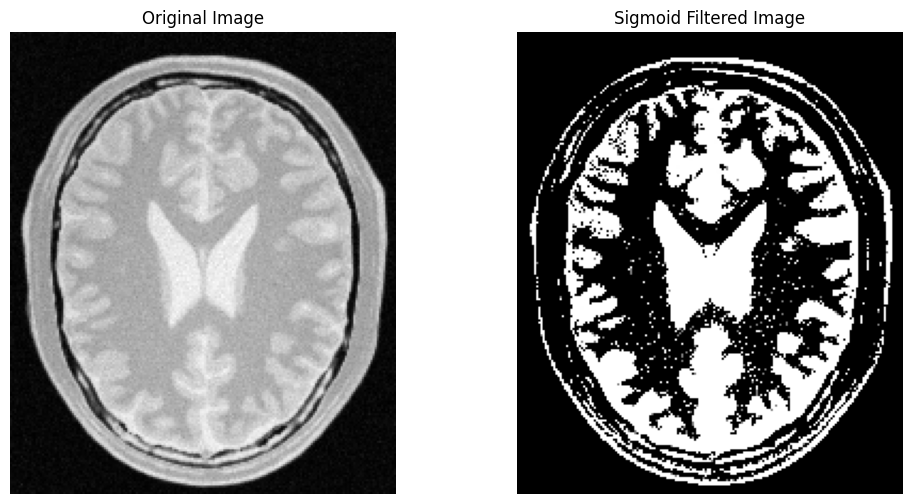

In [ ]:
# Sigmoid filter parameters
alpha = 10.0     # Steepness
beta = 180.0     # Midpoint intensity
output_min = 10.0
output_max = 240.0

# Convert to float for computation
img_float = input_image.astype(np.float32)

# Apply sigmoid formula
sigmoid_image = output_min + (output_max - output_min) / (1.0 + np.exp(alpha * (beta - img_float)))

# Clip and convert to uint8
sigmoid_image = np.clip(sigmoid_image, 0, 255).astype(np.uint8)

# Display original and sigmoid thresholded images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sigmoid_image, cmap='gray')
axes[1].set_title('Sigmoid Thresholded Image')
axes[1].axis('off')

plt.show()

# Filtering

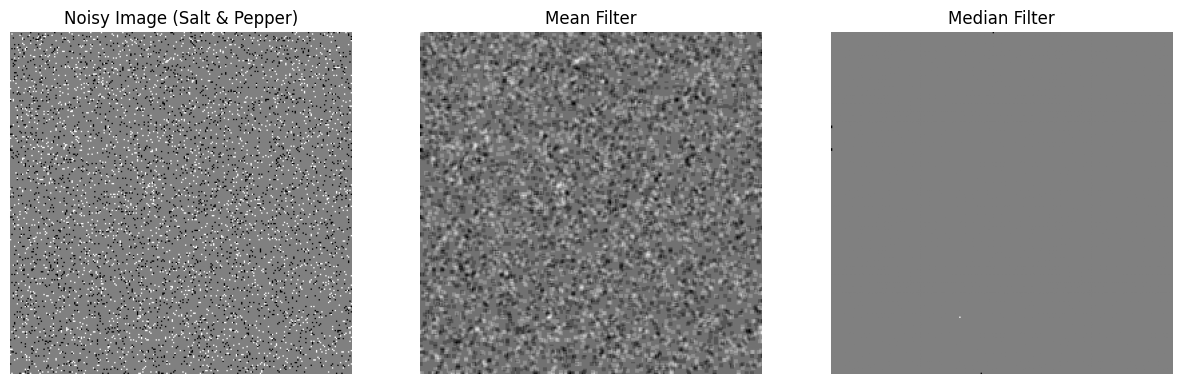

In [ ]:
# Function to add salt-and-pepper noise
def add_salt_and_pepper_noise(image, salt_prob, pepper_prob):
    noisy_image = image.copy()
    # Salt noise
    salt_mask = np.random.rand(*image.shape) < salt_prob
    noisy_image[salt_mask] = 255
    # Pepper noise
    pepper_mask = np.random.rand(*image.shape) < pepper_prob
    noisy_image[pepper_mask] = 0
    return noisy_image

# Create a sample image
image_size = (256, 256)
image = np.full(image_size, 128, dtype=np.uint8)

# Add salt-and-pepper noise
salt_prob = 0.05
pepper_prob = 0.05
noisy_image = add_salt_and_pepper_noise(image, salt_prob, pepper_prob)

# Apply mean filter
kernel_size = (3, 3)
mean_filtered = cv2.blur(noisy_image, kernel_size)

# Apply median filter
median_filtered = cv2.medianBlur(noisy_image, 3)  # 3x3 kernel

# Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(noisy_image, cmap='gray')
axes[0].set_title('Noisy Image (Salt & Pepper)')
axes[0].axis('off')

axes[1].imshow(mean_filtered, cmap='gray')
axes[1].set_title('Mean Filter')
axes[1].axis('off')

axes[2].imshow(median_filtered, cmap='gray')
axes[2].set_title('Median Filter')
axes[2].axis('off')

plt.show()


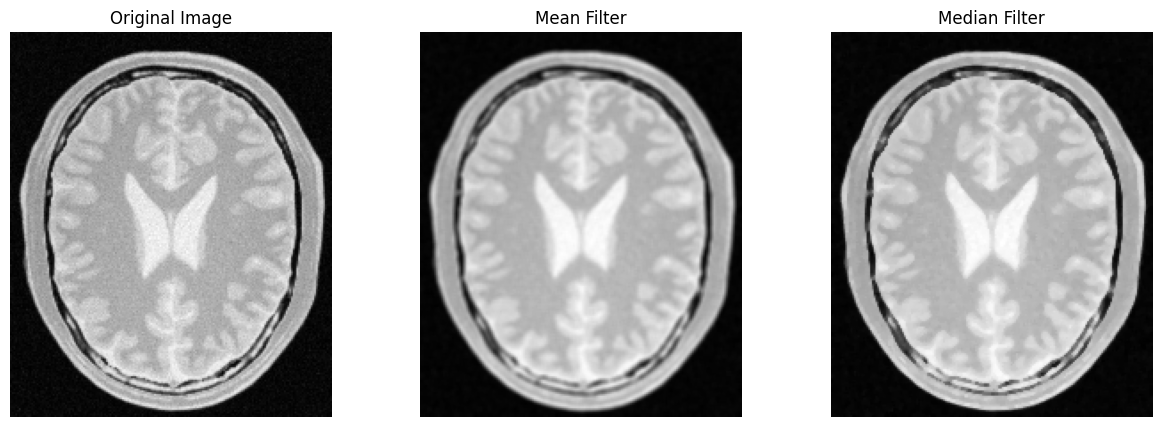

In [ ]:
# Apply mean filter
kernel_size = (3, 3)
mean_filtered = cv2.blur(input_image, kernel_size)

# Apply median filter
median_filtered = cv2.medianBlur(input_image, 3)  # 3x3 kernel

# Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(mean_filtered, cmap='gray')
axes[1].set_title('Mean Filter')
axes[1].axis('off')

axes[2].imshow(median_filtered, cmap='gray')
axes[2].set_title('Median Filter')
axes[2].axis('off')

plt.show()

# Edge Detection


In [ ]:
# Read image in grayscale
input_image_path = '/content/ChestX.png'
input_image = cv2.imread(input_image_path, cv2.IMREAD_GRAYSCALE)

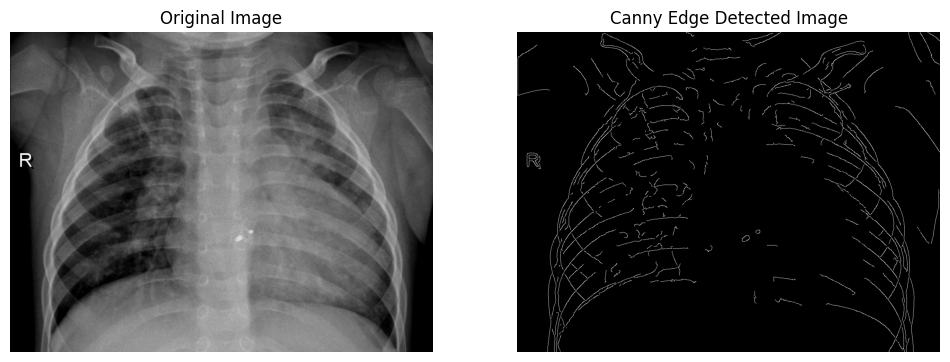

In [ ]:
# Parameters
variance = 3.0  # Gaussian smoothing variance

# Apply Gaussian blur for noise reduction
sigma = variance ** 0.5
blurred_image = cv2.GaussianBlur(input_image, (0, 0), sigma)

# Apply Canny edge detection
edges = cv2.Canny(blurred_image, 10, 50)

# Display original and edge-detected images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title('Canny Edge Detected Image')
axes[1].axis('off')

plt.show()


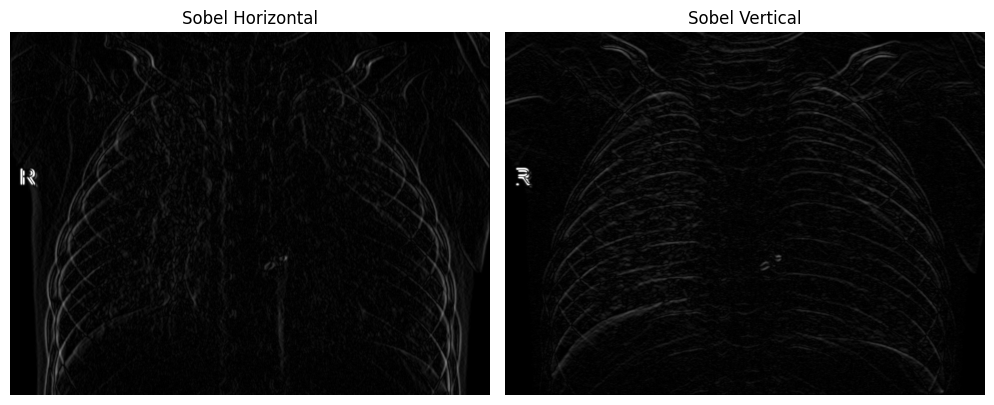

In [ ]:
# Sobel filtering
sobel_horizontal = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_horizontal = cv2.convertScaleAbs(sobel_horizontal)

sobel_vertical = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_vertical = cv2.convertScaleAbs(sobel_vertical)

# Display Results
titles = ['Sobel Horizontal', 'Sobel Vertical']
images = [sobel_horizontal, sobel_vertical]

plt.figure(figsize=(15, 10))
for i in range(len(images)):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


# Morphological Operations

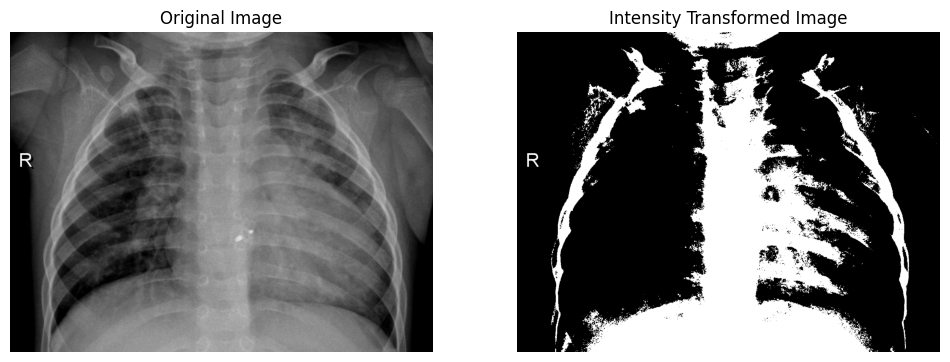

In [ ]:
# Intensity transformation
threshold_value = 120
white_value = 255  # White
black_value = 0   # Black

# Apply thresholding
_, transformed_image = cv2.threshold(input_image, threshold_value, white_value, cv2.THRESH_BINARY)

# Display original and transformed images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(input_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(transformed_image, cmap='gray')
axes[1].set_title('Intensity Transformed Image')
axes[1].axis('off')

plt.show()


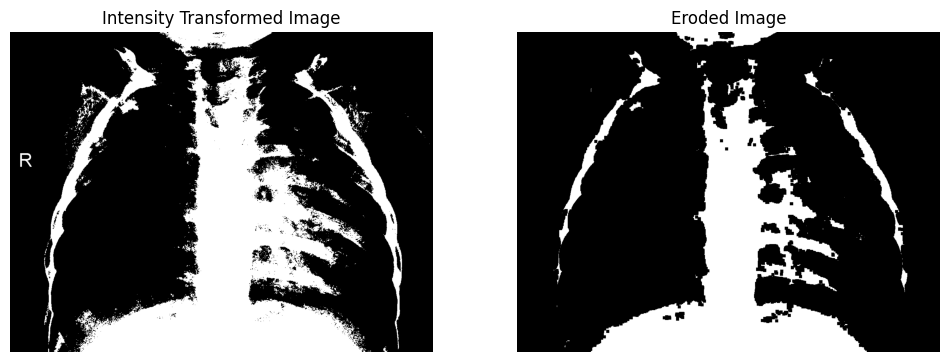

In [ ]:
# Apply morphological operations
kernel = np.ones((5, 5), np.uint8)

eroded = cv2.erode(transformed_image, kernel, iterations = 2)  # Erosion

# Display transformed image and erosion output
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(transformed_image, cmap='gray')
axes[0].set_title('Intensity Transformed Image')
axes[0].axis('off')

axes[1].imshow(eroded, cmap='gray')
axes[1].set_title('Eroded Image')
axes[1].axis('off')

plt.show()

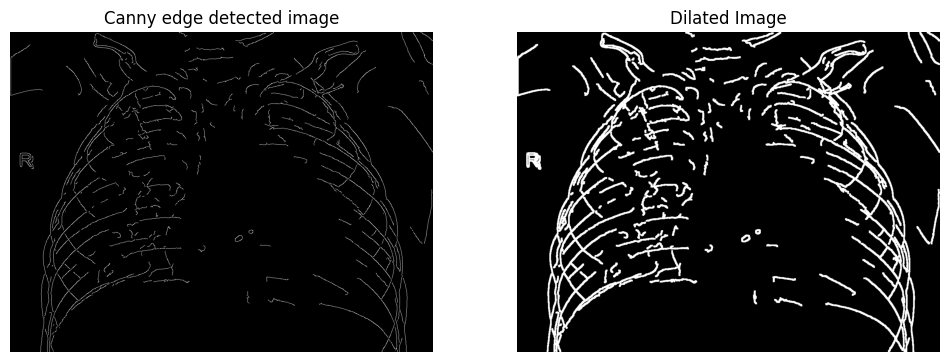

In [ ]:
# Apply morphological operations
kernel = np.ones((3, 3), np.uint8)

dilated = cv2.dilate(edges, kernel, iterations = 2) # Dilation

# Display Canny edges and dilated output
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(edges, cmap='gray')
axes[0].set_title('Canny edge detected image')
axes[0].axis('off')

axes[1].imshow(dilated, cmap='gray')
axes[1].set_title('Dilated Image')
axes[1].axis('off')

plt.show()